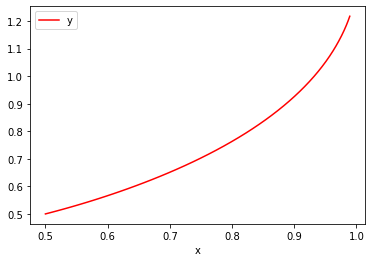

In [14]:
import sys
sys.path.append("../../")

#
# TO BE USED WITH godot/card2D_no_physics
#
import math

from lib.data.dataplot import *
from lib.system.cart import *
from lib.system.controllers import *
from lib.system.trajectory import *
from lib.system.polar import *
from lib.dds.dds import *
from lib.utils.time import *
from lib.utils.geometry import *

class SpeedControl2D:
    
    def __init__(self, _lin_params, _rot_params):
        """
        Construct a speed controller for a 2D robot.
        :params _lin_params: an array specifying [kp, ki, kd, Sat(Optional)] for linear controller
        :params _rot_params: an array specifying [kp, ki, kd, Sat(Optional)] for angular controller
        """
        self.linear_controller = PID_Controller(*_lin_params)
        self.rotation_controller = PID_Controller(*_rot_params)
        self.v_target = 0
        self.w_target = 0
    
    def set_v_target(self, v):
        self.v_target = v
        
    def set_w_target(self, w):
        self.w_target = w
        
    def set_targets(self, v, w):
        self.v_target = v
        self.w_target = w
        
    def evaluate(self, delta_t, v_current, w_current):
        v_error = self.v_target - v_current
        f_out = self.linear_controller.evaluate(delta_t, v_error)
        
        w_error = self.w_target - w_current
        t_out = self.rotation_controller.evaluate(delta_t, w_error)
        
        return (f_out, t_out)


class CircularTrajectory:
    
    def __init__(self, trajectory_radius, trajectory_angle, vmax, acc, dec):
        self.trajectory_angle = trajectory_angle
        self.trajectory_radius = trajectory_radius
        self.trajectory_length = trajectory_angle * abs(trajectory_radius)
        self.virtual_robot = VirtualRobot(self.trajectory_length, vmax, acc, dec)
        self.x_start = 0
        self.y_start = 0
        self.theta_start = 0
        
    def target_reached(self):
        return self.virtual_robot.phase == VirtualRobot.TARGET
        
    def set_initial_pose(self, x, y, th):
        self.x_start = x
        self.y_start = y
        self.theta_start = th

    def evaluate(self, delta_t):
        self.virtual_robot.evaluate(delta_t)
        alpha_t = self.virtual_robot.position() / abs(self.trajectory_radius)
        x = abs(self.trajectory_radius) * math.cos(math.pi/2 - alpha_t)
        y = self.trajectory_radius * math.sin(math.pi/2 - alpha_t) - self.trajectory_radius
        (x, y) = rototranslate(x, y, self.x_start, self.y_start, self.theta_start)
        return (x,y)
    
dds = DDS()
dds.start()

dds.subscribe(['tick'])

tdp = DataPlotter()
tdp.set_x("x")
tdp.add_y("y","y")


circle = CircularTrajectory(-1.0, math.radians(60),
                            1.0, # vmax
                            3.0,  # acc
                            3.0)  # dec

cart2d = Cart2D(1.0, 0.3, 0.9, 0.8)

speed_ctrl = SpeedControl2D([10.0, 6.0, 0.0], # parameters for linear speed controller
                            [1.0, 8.0, 0.0]) # parameters for angular speed controller

polar_position = Polar2DController(4, 1.0, # kp = 4, vmax = 1 m/s
                                   8, 6.0) # kp = 8, wmax = 6 rad/s

(xs, ys, ths) = (0.5, 0.5, math.radians(30))
#(xs, ys, ths) = (0.0, 0.0, math.radians(0))
cart2d.set_pose(xs, ys, ths)
circle.set_initial_pose(xs, ys, ths)

t = Time()
t.start()

while not(circle.target_reached()):
    dds.wait('tick')

    delta_t = t.elapsed()
    (x_target, y_target) = circle.evaluate(delta_t)
    
    pose = cart2d.get_pose()
    (v_target, w_target) = polar_position.evaluate(delta_t, x_target, y_target, pose)
    
    (v, w) = cart2d.get_speed()
    
    speed_ctrl.set_targets(v_target, w_target)
    (force, torque) = speed_ctrl.evaluate(delta_t, v, w)
    
    cart2d.evaluate(delta_t, force, torque)

    dds.publish('X', pose[0], DDS.DDS_TYPE_FLOAT)
    dds.publish('Y', pose[1], DDS.DDS_TYPE_FLOAT)
    dds.publish('Theta', pose[2], DDS.DDS_TYPE_FLOAT)
    
    tdp.append_x(pose[0])
    tdp.append_y("y",pose[1])
    
tdp.plot()

dds.stop()
